### Quadrotor Attack Effect Analysis

This notebook runs two standalone quadrotor scenarios and plots each result independently. The nominal section provides the baseline response, and the acoustic injection section uses the attack scenario with speaker power configured in the YAML file.

In [26]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "scenarios").is_dir() and (path / "src" / "cp_glimpse_py").is_dir():
            return path
    raise RuntimeError("Could not find FIRE_CP_Glimpse repository root.")


REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (11, 7),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print(REPO_ROOT)

/home/mhcho/ws/FIRE_CP_Glimpse


In [27]:
SCENARIOS = {
    "nominal": REPO_ROOT / "scenarios" / "quadrotor_nominal.yaml",
    "acoustic_attack": REPO_ROOT / "scenarios" / "quadrotor_acoustic_attack.yaml",
}

OUTPUTS = {
    name: RESULTS_DIR / name / "outputs.csv"
    for name in SCENARIOS
}

# Set this to False if you only want to reload existing CSV files.
RUN_SIMULATIONS = True

#### Shared Helpers

These cells locate the repository, define scenario/result paths, run simulations through the CLI, load CSV outputs, and provide reusable plotting helpers.

In [28]:
def run_scenario(name: str) -> Path:
    scenario_path = SCENARIOS[name]
    save_dir = OUTPUTS[name].parent
    save_dir.mkdir(parents=True, exist_ok=True)

    env = os.environ.copy()
    src_path = str(REPO_ROOT / "src")
    env["PYTHONPATH"] = src_path + os.pathsep + env.get("PYTHONPATH", "")

    cmd = [
        sys.executable,
        "-m",
        "cp_glimpse_py.main",
        "--scenario",
        str(scenario_path),
        "--save-dir",
        str(save_dir),
    ]
    completed = subprocess.run(
        cmd,
        cwd=REPO_ROOT,
        env=env,
        text=True,
        capture_output=True,
        check=False,
    )
    if completed.returncode != 0:
        print(completed.stdout[-4000:])
        print(completed.stderr[-4000:])
        raise RuntimeError(f"{name} simulation failed with exit code {completed.returncode}.")

    print(completed.stdout[-1000:])
    return OUTPUTS[name]


def load_result(name: str) -> pd.DataFrame:
    output = OUTPUTS[name]
    if not output.exists():
        raise FileNotFoundError(f"Run the {name} scenario first: {output}")
    return pd.read_csv(output)


def require_columns(df: pd.DataFrame, columns: list[str]) -> list[str]:
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError("Missing columns: " + ", ".join(missing))
    return columns


def plot_3d_position(df: pd.DataFrame, title: str) -> None:
    cols = require_columns(df, [
        "quadrotor.quad_low.position_w_p_w[1]",
        "quadrotor.quad_low.position_w_p_w[2]",
        "quadrotor.quad_low.position_w_p_w[3]",
    ])
    x, y, z = [df[col] for col in cols]

    fig = plt.figure(figsize=(9, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(x, y, z, linewidth=2)
    ax.scatter(x.iloc[0], y.iloc[0], z.iloc[0], s=50, label="start")
    ax.scatter(x.iloc[-1], y.iloc[-1], z.iloc[-1], s=50, label="end")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_zlabel("z [m]")
    ax.set_title(title)
    ax.legend(loc="best")
    plt.show()


def plot_timeseries(df: pd.DataFrame, columns: list[str], title: str, ylabel: str = "") -> None:
    cols = require_columns(df, columns)
    fig, axes = plt.subplots(len(cols), 1, sharex=True, figsize=(11, 2.7 * len(cols)))
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        ax.plot(df["time"], df[col])
        ax.set_title(col)
        ax.set_ylabel(ylabel or col.split(".")[-1])

    axes[-1].set_xlabel("time [s]")
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()

#### Nominal Scenario

Runs `quadrotor_nominal.yaml` and loads the generated result CSV from `results/nominal/outputs.csv`. Use this section to inspect the baseline closed-loop flight behavior.

In [29]:
if RUN_SIMULATIONS:
    run_scenario("nominal")

nominal = load_result("nominal")
nominal.shape

ress] t=9.865/10s
[simulation progress] t=9.87/10s
[simulation progress] t=9.875/10s
[simulation progress] t=9.88/10s
[simulation progress] t=9.885/10s
[simulation progress] t=9.89/10s
[simulation progress] t=9.895/10s
[simulation progress] t=9.9/10s
[simulation progress] t=9.905/10s
[simulation progress] t=9.91/10s
[simulation progress] t=9.915/10s
[simulation progress] t=9.92/10s
[simulation progress] t=9.925/10s
[simulation progress] t=9.93/10s
[simulation progress] t=9.935/10s
[simulation progress] t=9.94/10s
[simulation progress] t=9.945/10s
[simulation progress] t=9.95/10s
[simulation progress] t=9.955/10s
[simulation progress] t=9.96/10s
[simulation progress] t=9.965/10s
[simulation progress] t=9.97/10s
[simulation progress] t=9.975/10s
[simulation progress] t=9.98/10s
[simulation progress] t=9.985/10s
[simulation progress] t=9.99/10s
[simulation progress] t=9.995/10s
[simulation progress] t=10/10s
Saved CSV results to: /home/mhcho/ws/FIRE_CP_Glimpse/results/nominal/outputs.csv


(2001, 32)

##### Nominal Case: Trajectory and Plots

Plots the baseline flight path in 3D using the quadrotor world-frame position states. <br>
Plots the position / velocity / attitude / angular rate timeseries.

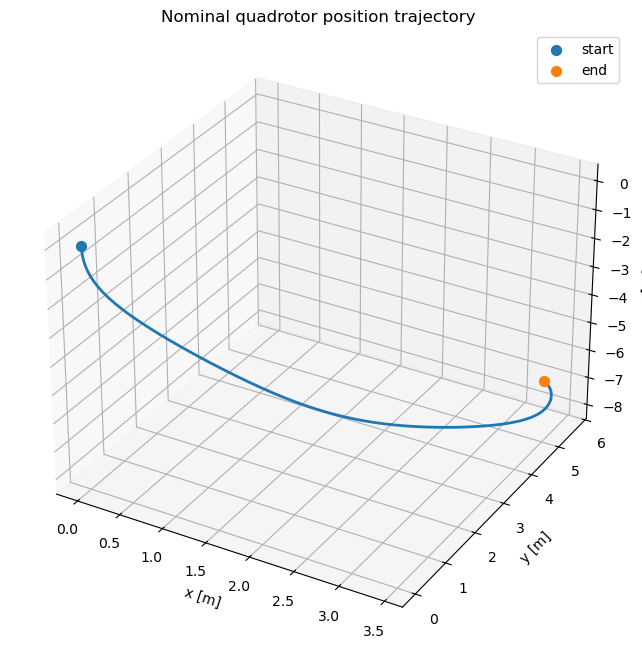

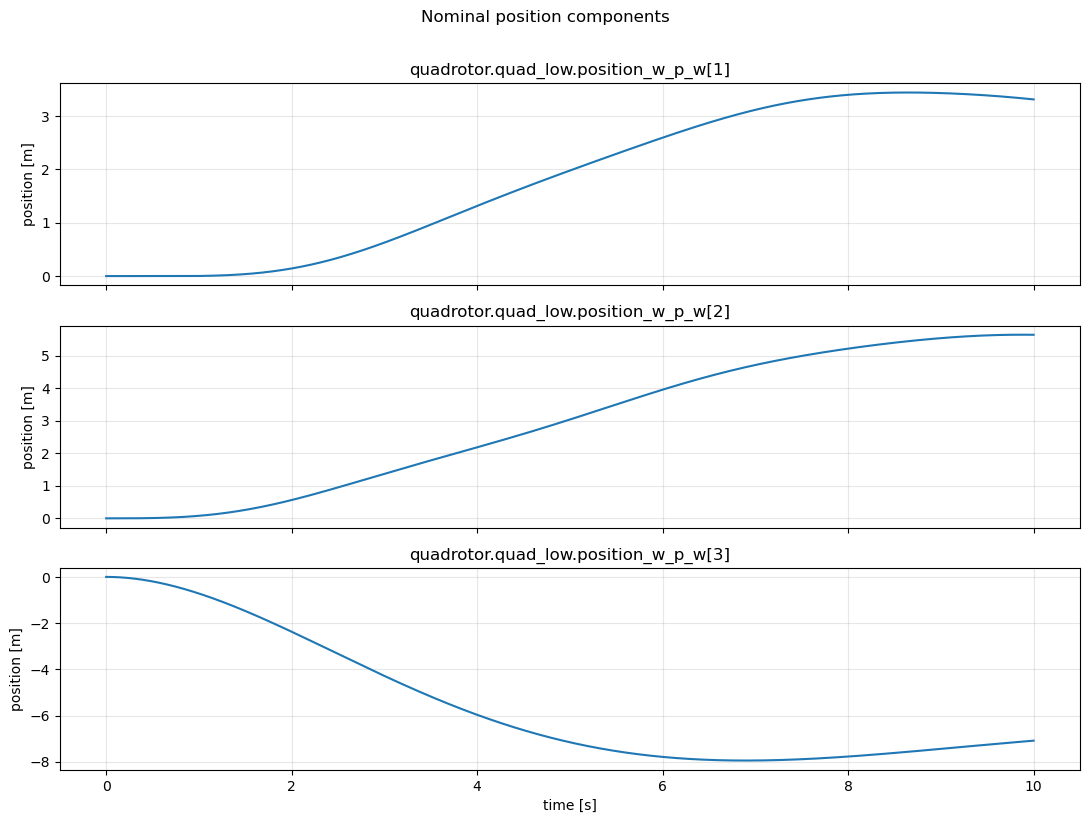

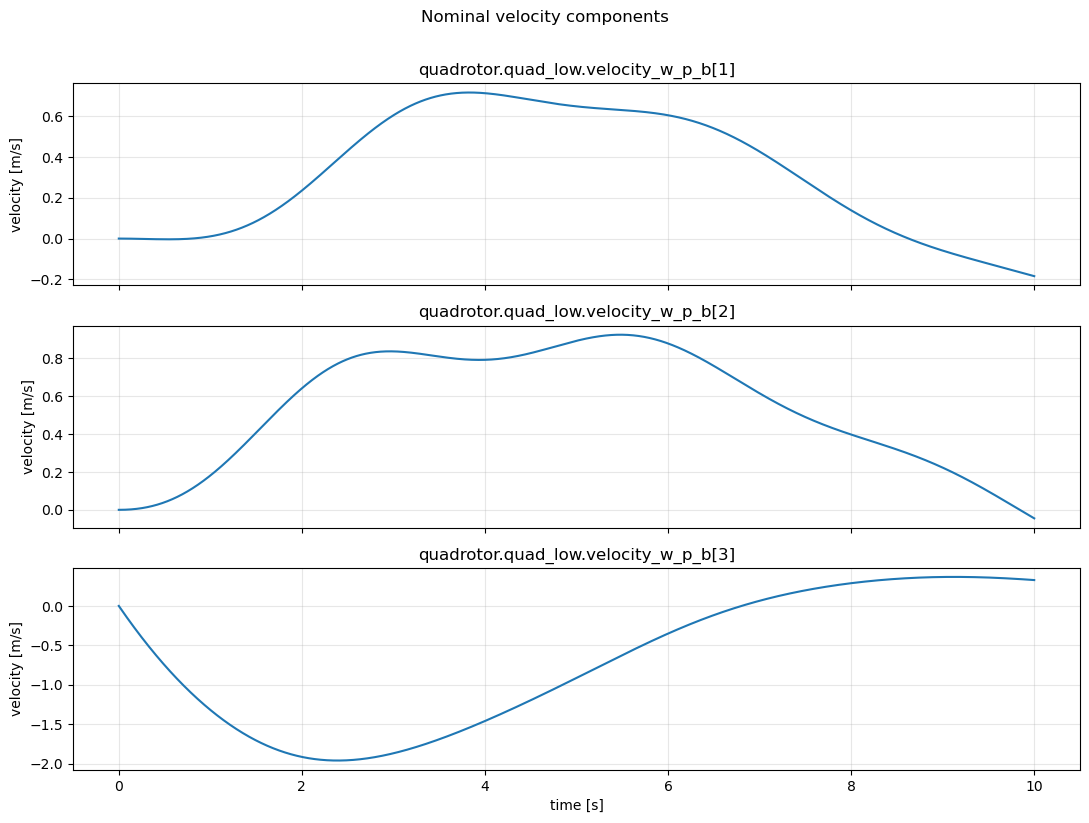

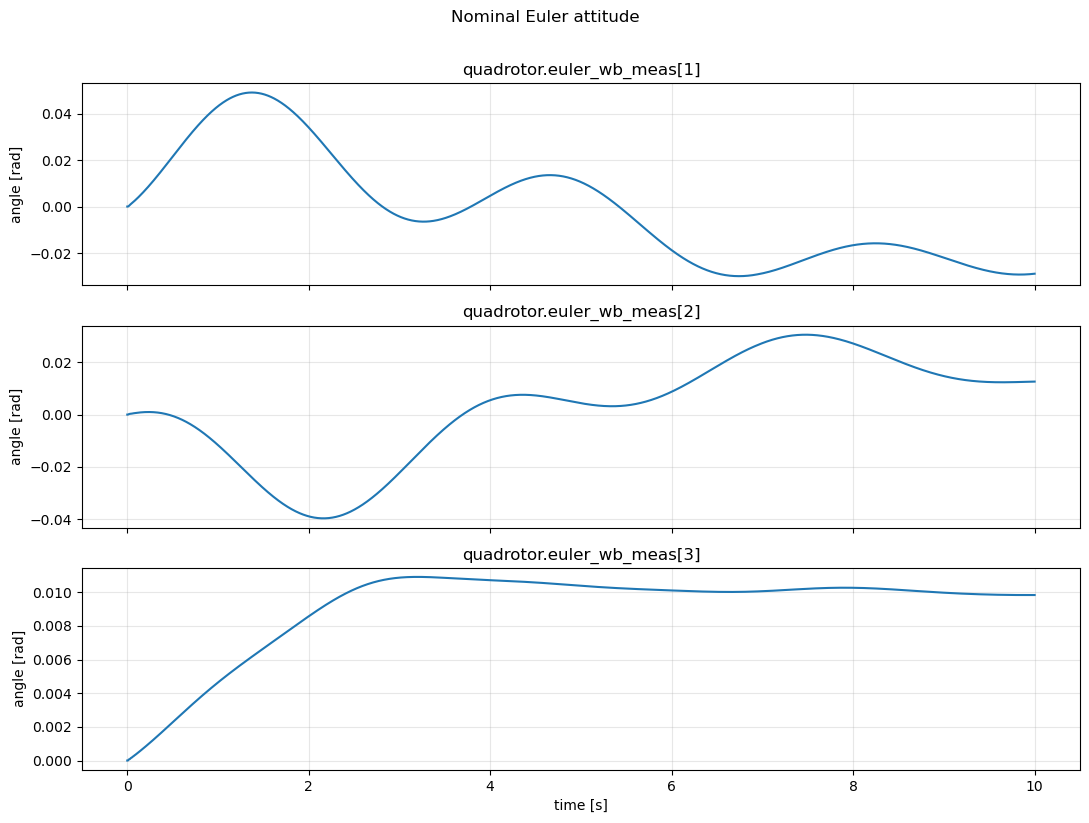

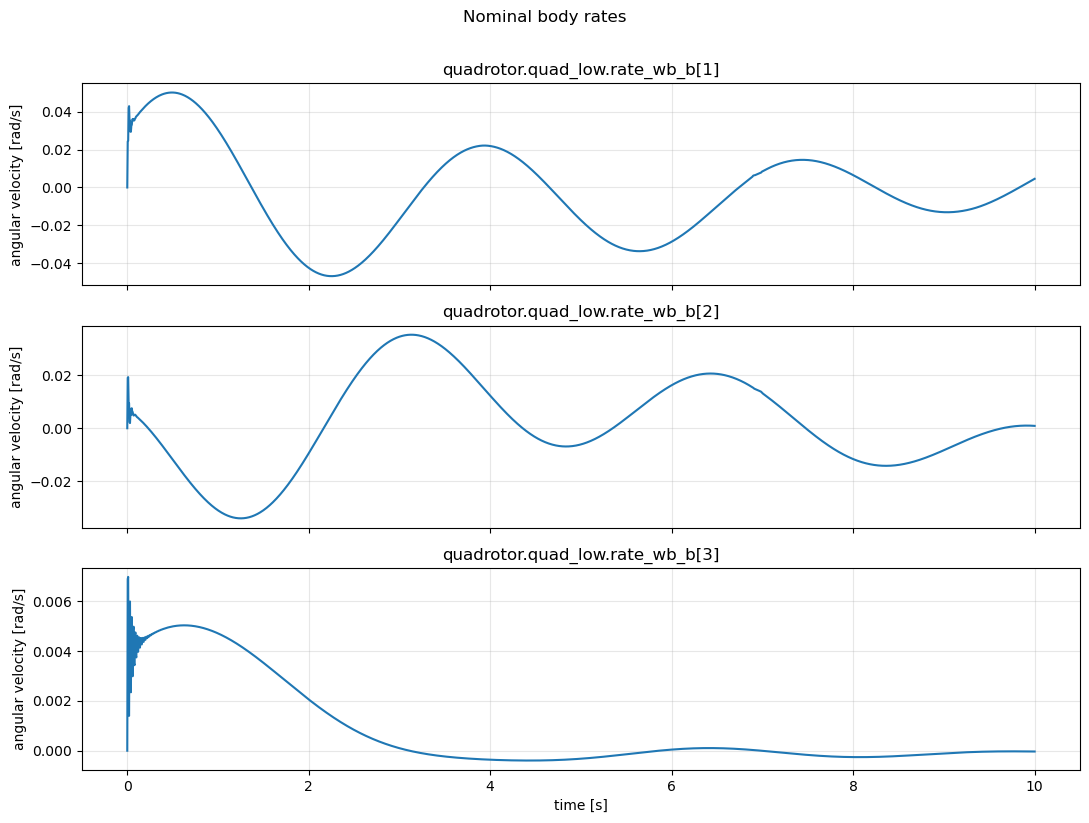

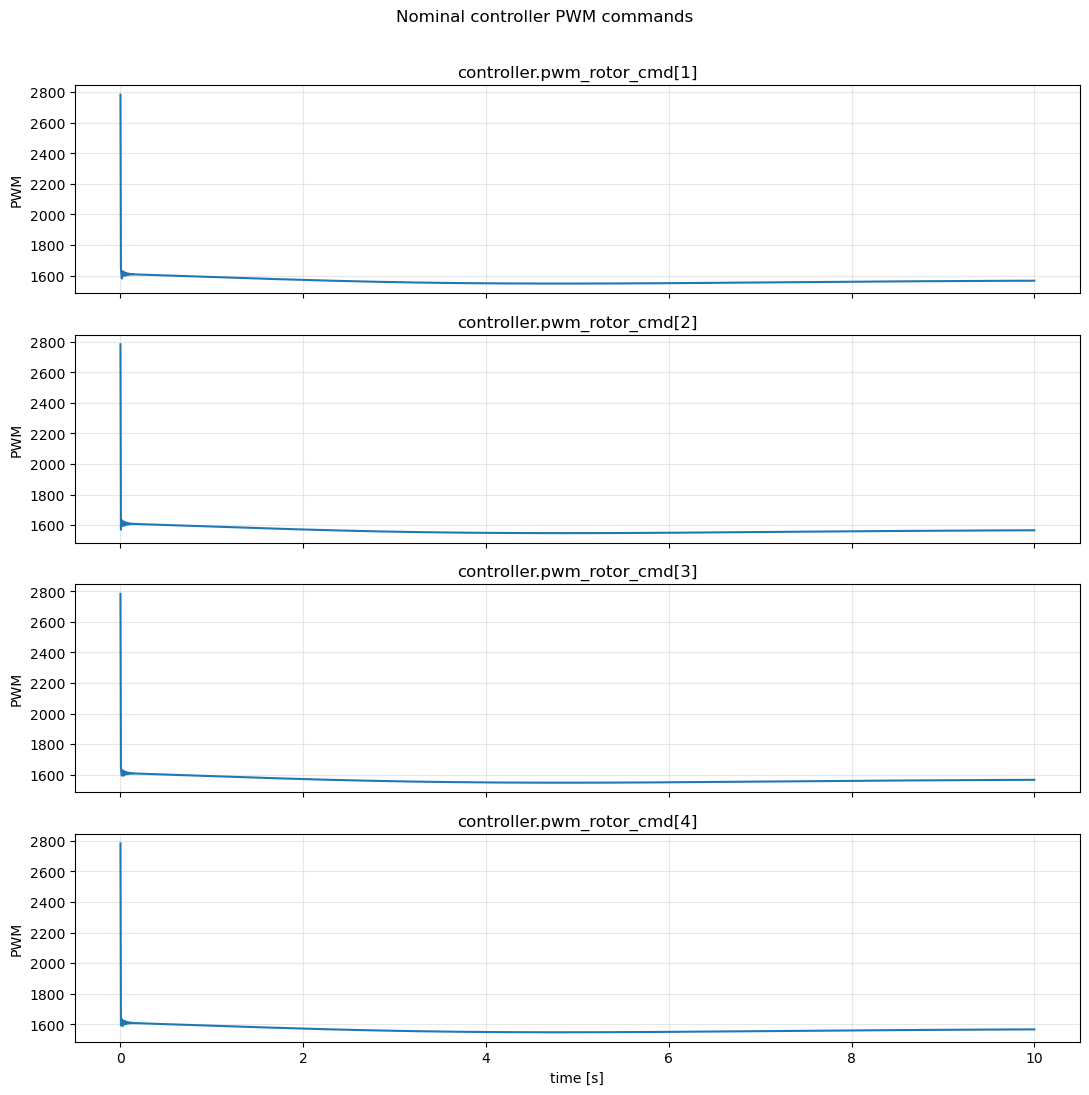

In [33]:
plot_3d_position(nominal, "Nominal quadrotor position trajectory")

plot_timeseries(
    nominal,
    [
        "quadrotor.quad_low.position_w_p_w[1]",
        "quadrotor.quad_low.position_w_p_w[2]",
        "quadrotor.quad_low.position_w_p_w[3]",
    ],
    "Nominal position components",
    "position [m]",
)

plot_timeseries(
    nominal,
    [
        "quadrotor.quad_low.velocity_w_p_b[1]",
        "quadrotor.quad_low.velocity_w_p_b[2]",
        "quadrotor.quad_low.velocity_w_p_b[3]",
    ],
    "Nominal velocity components",
    "velocity [m/s]",
)

plot_timeseries(
    nominal,
    [
        "quadrotor.euler_wb_meas[1]",
        "quadrotor.euler_wb_meas[2]",
        "quadrotor.euler_wb_meas[3]",
    ],
    "Nominal Euler attitude",
    "angle [rad]",
)

plot_timeseries(
    nominal,
    [
        "quadrotor.quad_low.rate_wb_b[1]",
        "quadrotor.quad_low.rate_wb_b[2]",
        "quadrotor.quad_low.rate_wb_b[3]",
    ],
    "Nominal body rates",
    "angular velocity [rad/s]",
)

plot_timeseries(
    nominal,
    [
        "controller.pwm_rotor_cmd[1]",
        "controller.pwm_rotor_cmd[2]",
        "controller.pwm_rotor_cmd[3]",
        "controller.pwm_rotor_cmd[4]",
    ],
    "Nominal controller PWM commands",
    "PWM",
)

#### Acoustic Injection Attack Scenario

Runs `quadrotor_acoustic_attack.yaml` and loads the generated result CSV from `results/acoustic_attack/outputs.csv`. This scenario applies the gyroscope acoustic injection parameters defined in the scenario file.

In [23]:
if RUN_SIMULATIONS:
    run_scenario("acoustic_attack")

acoustic_attack = load_result("acoustic_attack")
acoustic_attack.shape

9.865/10s
[simulation progress] t=9.87/10s
[simulation progress] t=9.875/10s
[simulation progress] t=9.88/10s
[simulation progress] t=9.885/10s
[simulation progress] t=9.89/10s
[simulation progress] t=9.895/10s
[simulation progress] t=9.9/10s
[simulation progress] t=9.905/10s
[simulation progress] t=9.91/10s
[simulation progress] t=9.915/10s
[simulation progress] t=9.92/10s
[simulation progress] t=9.925/10s
[simulation progress] t=9.93/10s
[simulation progress] t=9.935/10s
[simulation progress] t=9.94/10s
[simulation progress] t=9.945/10s
[simulation progress] t=9.95/10s
[simulation progress] t=9.955/10s
[simulation progress] t=9.96/10s
[simulation progress] t=9.965/10s
[simulation progress] t=9.97/10s
[simulation progress] t=9.975/10s
[simulation progress] t=9.98/10s
[simulation progress] t=9.985/10s
[simulation progress] t=9.99/10s
[simulation progress] t=9.995/10s
[simulation progress] t=10/10s
Saved CSV results to: /home/mhcho/ws/FIRE_CP_Glimpse/results/acoustic_attack/outputs.csv


(2001, 32)

##### Acoustic Noise Injection Attack Case: Trajectory and Plots

Plots the attacked flight path in 3D using the quadrotor world-frame position states. <br>
Plots the position / velocity / attitude / angular rate timeseries.

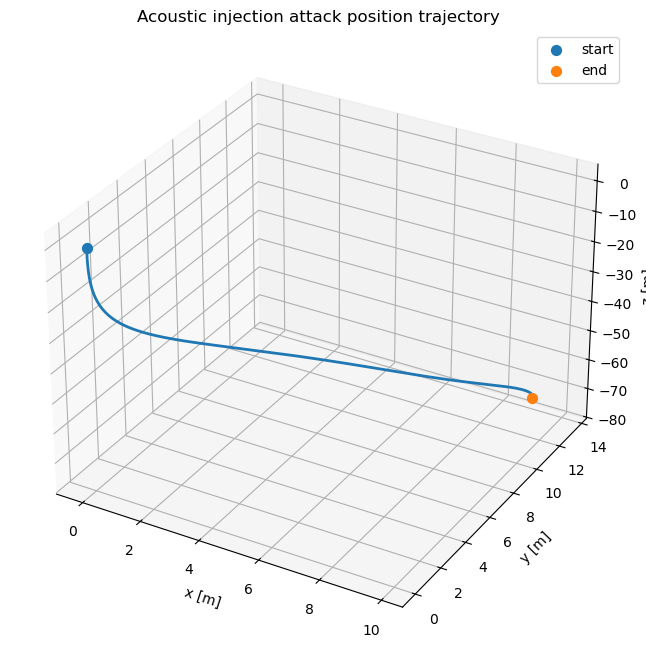

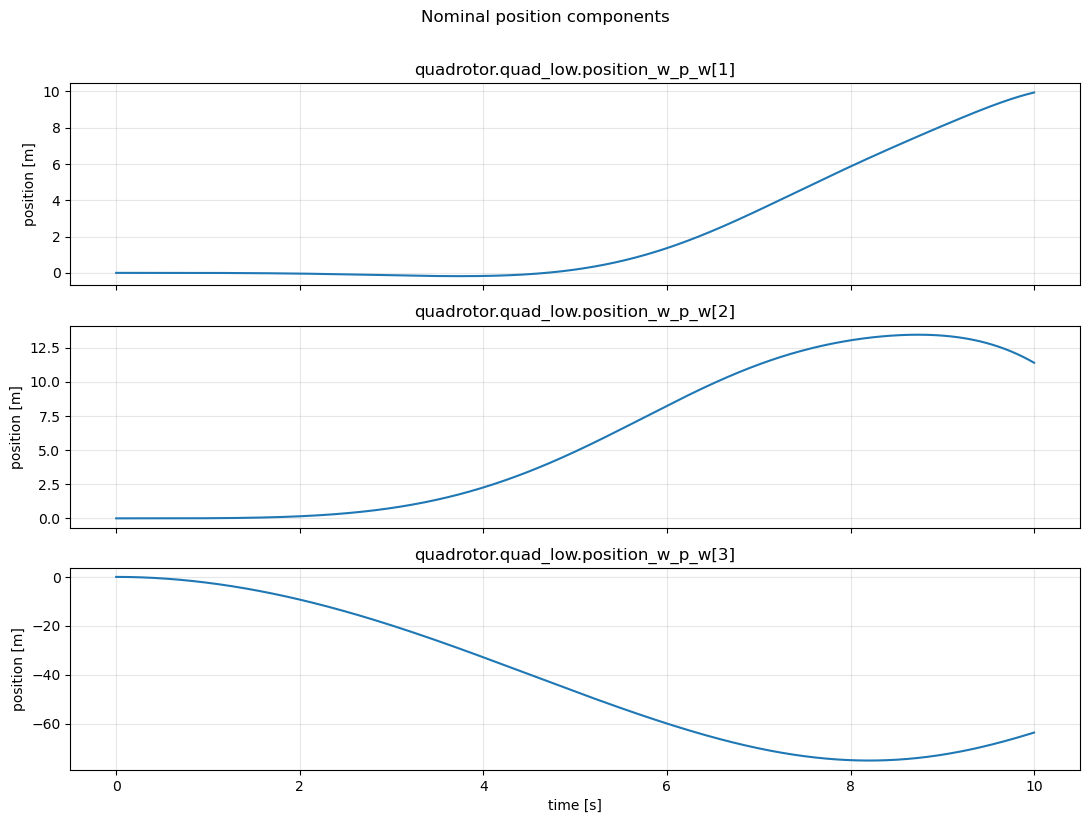

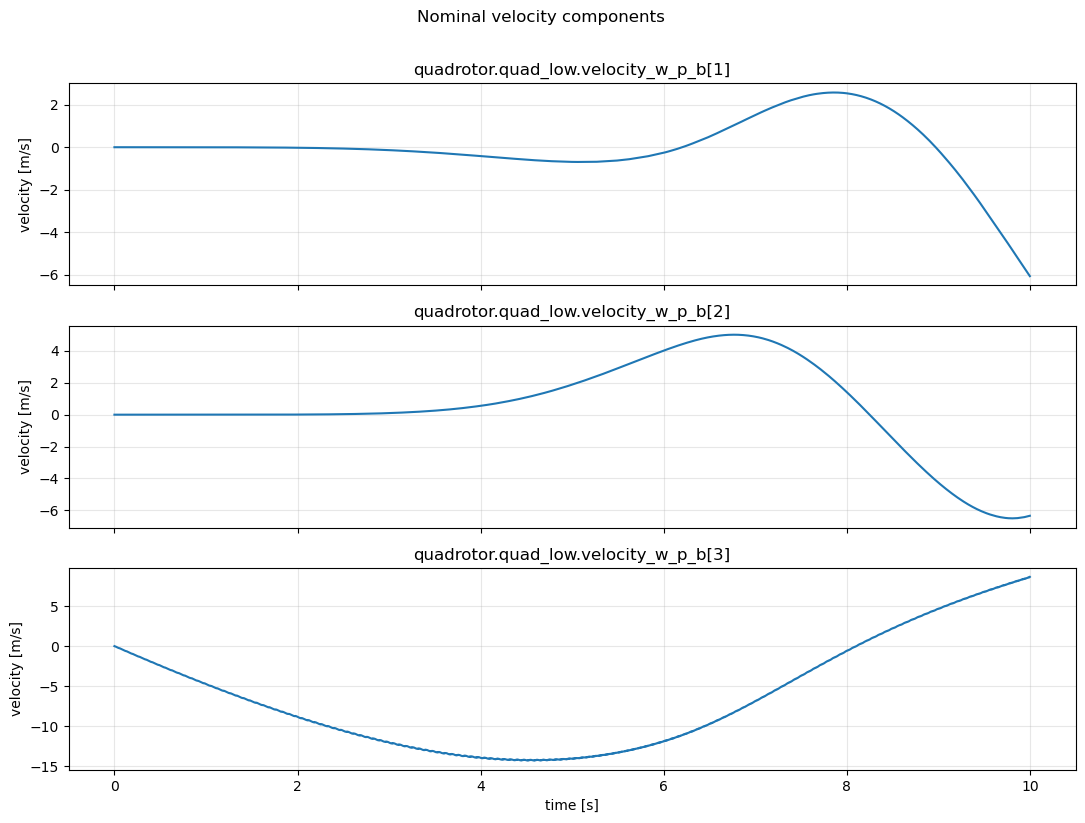

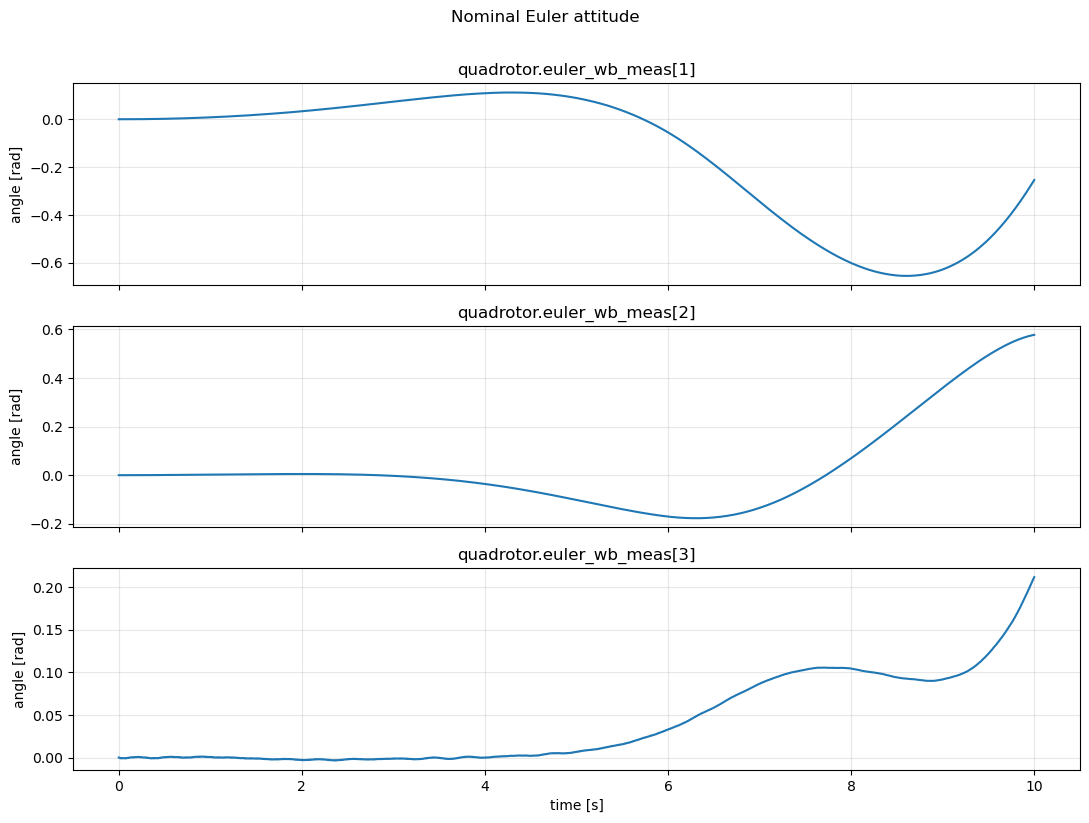

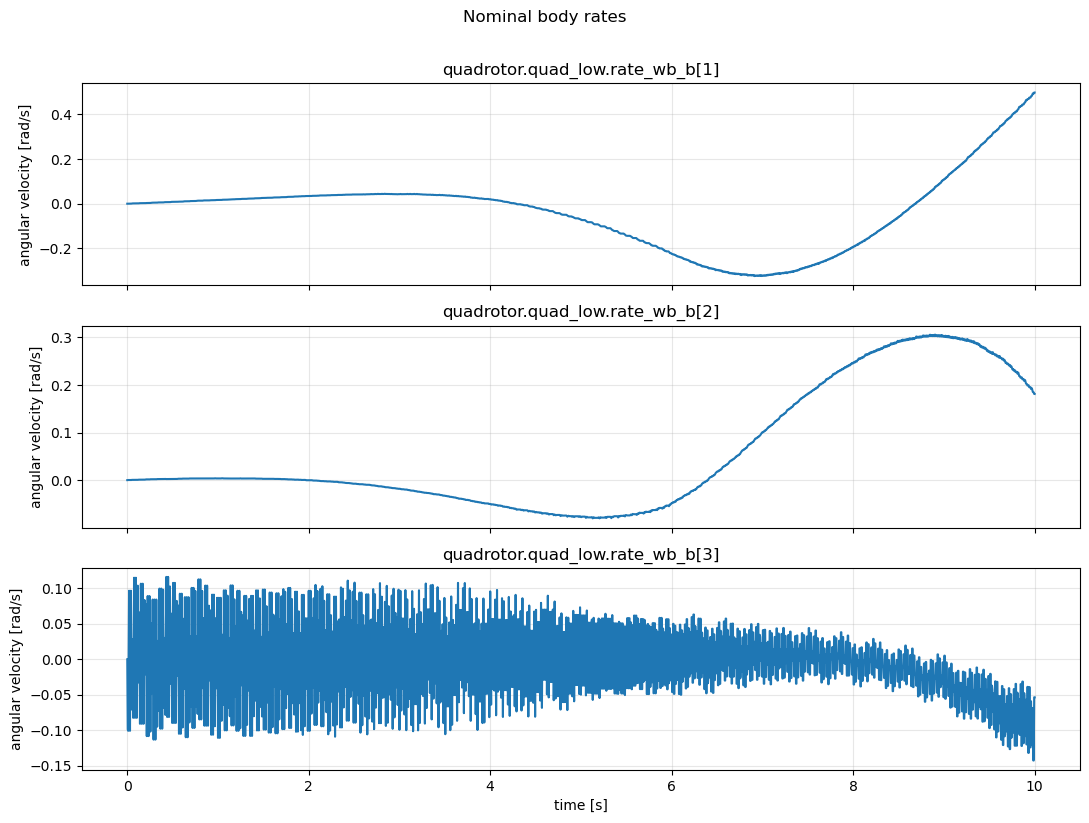

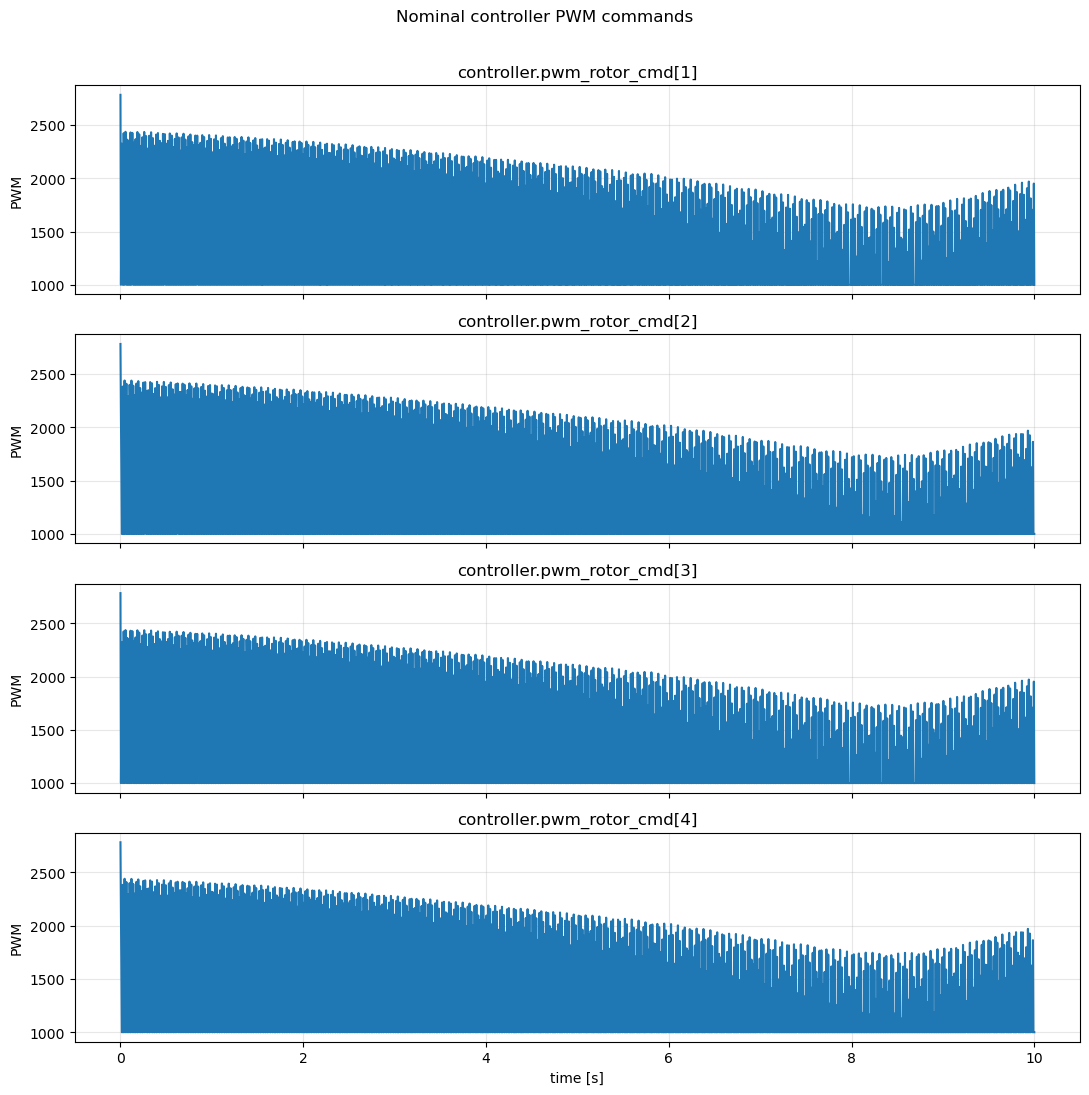

In [34]:
plot_3d_position(acoustic_attack, "Acoustic injection attack position trajectory")

plot_timeseries(
    acoustic_attack,
    [
        "quadrotor.quad_low.position_w_p_w[1]",
        "quadrotor.quad_low.position_w_p_w[2]",
        "quadrotor.quad_low.position_w_p_w[3]",
    ],
    "Nominal position components",
    "position [m]",
)

plot_timeseries(
    acoustic_attack,
    [
        "quadrotor.quad_low.velocity_w_p_b[1]",
        "quadrotor.quad_low.velocity_w_p_b[2]",
        "quadrotor.quad_low.velocity_w_p_b[3]",
    ],
    "Nominal velocity components",
    "velocity [m/s]",
)

plot_timeseries(
    acoustic_attack,
    [
        "quadrotor.euler_wb_meas[1]",
        "quadrotor.euler_wb_meas[2]",
        "quadrotor.euler_wb_meas[3]",
    ],
    "Nominal Euler attitude",
    "angle [rad]",
)

plot_timeseries(
    acoustic_attack,
    [
        "quadrotor.quad_low.rate_wb_b[1]",
        "quadrotor.quad_low.rate_wb_b[2]",
        "quadrotor.quad_low.rate_wb_b[3]",
    ],
    "Nominal body rates",
    "angular velocity [rad/s]",
)

plot_timeseries(
    acoustic_attack,
    [
        "controller.pwm_rotor_cmd[1]",
        "controller.pwm_rotor_cmd[2]",
        "controller.pwm_rotor_cmd[3]",
        "controller.pwm_rotor_cmd[4]",
    ],
    "Nominal controller PWM commands",
    "PWM",
)